# SHAP Interpretability Analysis

This notebook uses SHAP to explain which genes drive the XGBoost model predictions.

**Output:** Top genes saved to `reports/shap_top20_genes.csv`

In [1]:
pip install numpy==2.3.0 --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [3]:
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

model = joblib.load('../models/xgboost_model.joblib')
print(f"Data loaded: {X_test.shape}")

Data loaded: (142, 1000)


In [4]:
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [5]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (142, 1000)


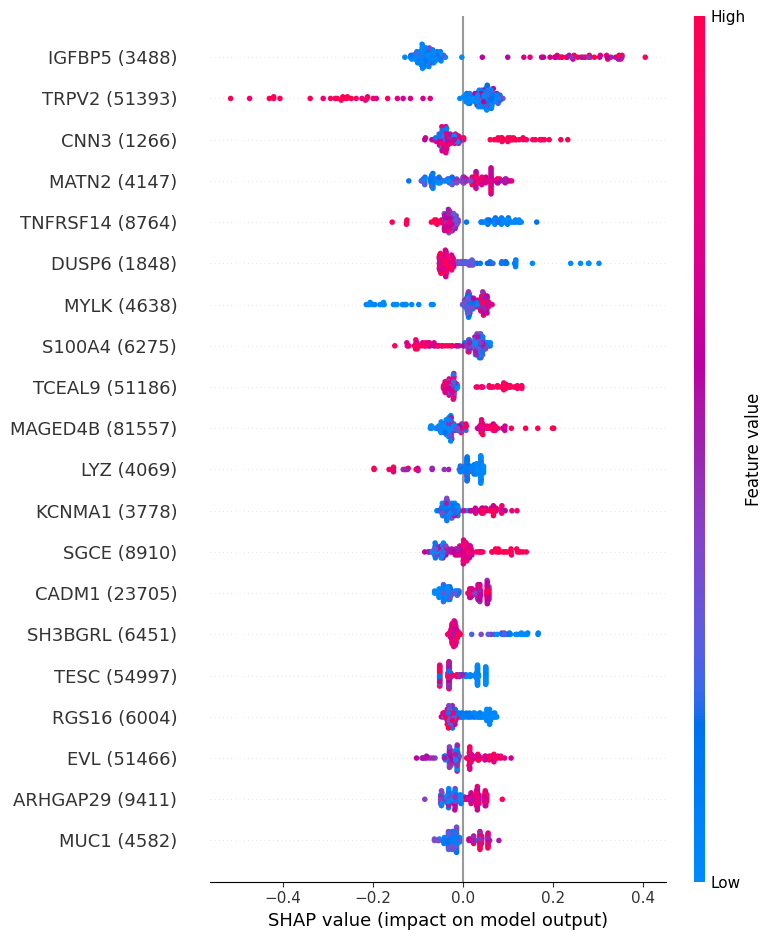

In [6]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

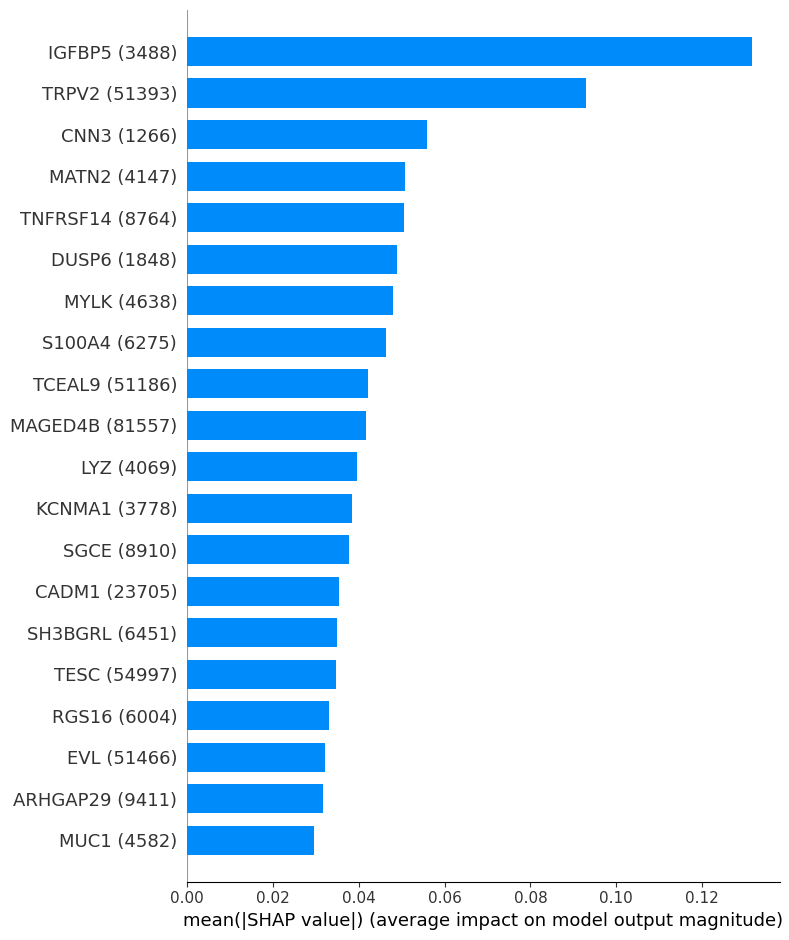

In [8]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Top gene: IGFBP5 (3488)


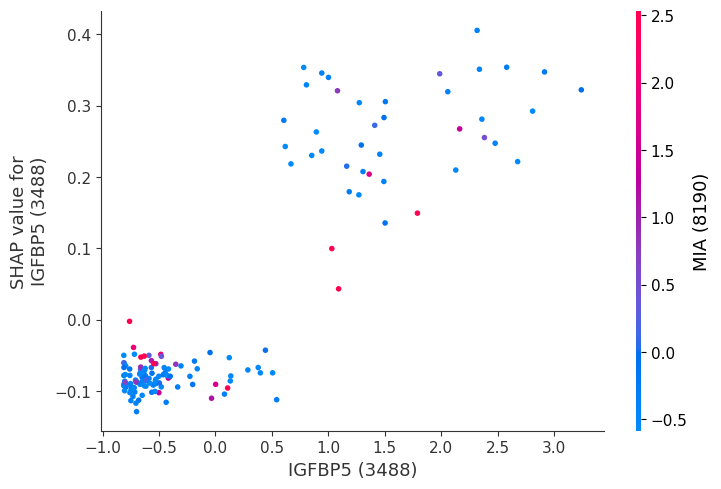

In [9]:
top_gene = X_test.columns[np.abs(shap_values).mean(0).argmax()]
print(f"Top gene: {top_gene}")

shap.dependence_plot(top_gene, shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_top.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
top_10_idx = np.abs(shap_values).mean(0).argsort()[-10:][::-1]
top_10_genes = X_test.columns[top_10_idx].tolist()

print("Top 10 genes by SHAP importance:")
for i, gene in enumerate(top_10_genes, 1):
    print(f"{i}. {gene}")

Top 10 genes by SHAP importance:
1. IGFBP5 (3488)
2. TRPV2 (51393)
3. CNN3 (1266)
4. MATN2 (4147)
5. TNFRSF14 (8764)
6. DUSP6 (1848)
7. MYLK (4638)
8. S100A4 (6275)
9. TCEAL9 (51186)
10. MAGED4B (81557)


In [11]:
shap.initjs()
sample_idx = 0
shap.force_plot(explainer.expected_value, shap_values[sample_idx], X_test.iloc[sample_idx])

In [12]:
mean_shap = np.abs(shap_values).mean(0)
shap_importance = pd.DataFrame({
    'gene': X_test.columns,
    'shap_importance': mean_shap
}).sort_values('shap_importance', ascending=False)

shap_importance.head(20).to_csv('../reports/shap_top20_genes.csv', index=False)
print("Top 20 genes saved to reports/shap_top20_genes.csv")
print(shap_importance.head(10))

Top 20 genes saved to reports/shap_top20_genes.csv
                gene  shap_importance
122    IGFBP5 (3488)         0.131563
923    TRPV2 (51393)         0.092857
203      CNN3 (1266)         0.056002
638     MATN2 (4147)         0.050765
944  TNFRSF14 (8764)         0.050465
603     DUSP6 (1848)         0.048948
824      MYLK (4638)         0.047958
70     S100A4 (6275)         0.046284
279   TCEAL9 (51186)         0.042136
387  MAGED4B (81557)         0.041675


In [13]:
print("="*50)
print("SHAP ANALYSIS SUMMARY")
print("="*50)
print(f"Samples analyzed: {X_test.shape[0]}")
print(f"Features analyzed: {X_test.shape[1]}")
print(f"Top predictive gene: {top_10_genes[0]}")
print(f"Expected value (baseline): {explainer.expected_value:.3f}")
print("="*50)


SHAP ANALYSIS SUMMARY
Samples analyzed: 142
Features analyzed: 1000
Top predictive gene: IGFBP5 (3488)
Expected value (baseline): 2.748
